# Laboratorio Semana 4: Seq2Seq Ingles-Espanol desde cero

**Curso:** Deep Learning  
**Valor:** 4% de la nota del curso  
**Entrega:** Notebook ejecutado (.ipynb) con todas las celdas con salida visible

---

## Contexto

Esta semana implementa un modelo Seq2Seq completo para traduccion ingles-espanol con traducciones **naturales en espanol**: el corpus tiene deliberadamente oraciones donde el espanol es mas corto (por elision del sujeto: *she sings well* -> *canta bien*), mas largo (por perifrasis verbales: *the cat sleeps* -> *el gato esta durmiendo*), o del mismo largo. Esa asimetria de largo es exactamente la razon de ser de la arquitectura Encoder-Decoder.

Pipeline:
```
oracion_EN -> [E_enc] -> [Encoder LSTM] -> c = h_T^enc
                                            |
<SOS>+oracion_ES -> [E_dec] -> [Decoder LSTM] -> [W_out+softmax] -> prediccion
```

## Reglas

- Use unicamente PyTorch. No use `nn.LSTM`, `nn.Embedding`, `nn.Linear` ni capas de alto nivel.
- El backward debe ser **manual**. No use `loss.backward()`.
- No modifique los pesos iniciales ni el corpus.
- La celda final calcula su nota automatica sobre los **60 puntos** de codigo.

In [1]:
import torch
import torch.nn.functional as F
import hashlib, numpy as np, random, time
from collections import Counter
import matplotlib.pyplot as plt

def _hash_tensor(t, decimals=5):
    arr = np.round(t.detach().numpy().astype(np.float64), decimals)
    return hashlib.sha256(arr.tobytes()).hexdigest()

_resultados = {}
print(f'PyTorch: {torch.__version__}')

PyTorch: 2.11.0+cpu


---
## Bloque 0: Corpus, vocabularios y pesos iniciales (dado, no modificar)

In [2]:
CORPUS_COMPLETO = [
    ("i love you", "te amo"),
    ("i drink water", "bebo agua"),
    ("i read the news", "leo las noticias"),
    ("i write a book", "escribo un libro"),
    ("i hear music", "escucho musica"),
    ("i call my mother", "llamo a mi madre"),
    ("i take a photo", "tomo una foto"),
    ("i finish my work", "termino mi trabajo"),
    ("i open the book", "abro el libro"),
    ("i run every morning", "corro cada manana"),
    ("i learn spanish", "aprendo espanol"),
    ("i like coffee", "me gusta el cafe"),
    ("i work every day", "trabajo todos los dias"),
    ("i buy fresh bread", "compro pan fresco"),
    ("she reads books", "lee libros"),
    ("she sings well", "canta bien"),
    ("she cooks dinner", "cocina la cena"),
    ("she opens the door", "abre la puerta"),
    ("she sleeps early", "duerme temprano"),
    ("she buys flowers", "compra flores"),
    ("she draws pictures", "dibuja imagenes"),
    ("she visits her friend", "visita a su amiga"),
    ("she teaches math", "ensena matematica"),
    ("she paints a picture", "pinta un cuadro"),
    ("she writes a poem", "escribe un poema"),
    ("she enjoys the music", "disfruta la musica"),
    ("she prepares the meal", "prepara la comida"),
    ("he runs fast", "corre rapido"),
    ("he writes a letter", "escribe una carta"),
    ("he closes the window", "cierra la ventana"),
    ("he eats an apple", "come una manzana"),
    ("he drives a car", "conduce un carro"),
    ("he fixes the bike", "arregla la bicicleta"),
    ("he plays the guitar", "toca la guitarra"),
    ("he studies history", "estudia historia"),
    ("he answers the phone", "contesta el telefono"),
    ("he repairs the chair", "repara la silla"),
    ("he teaches the class", "ensena la clase"),
    ("we eat bread", "comemos pan"),
    ("we walk together", "caminamos juntos"),
    ("we leave early", "salimos temprano"),
    ("we cook together", "cocinamos juntos"),
    ("we swim in the sea", "nadamos en el mar"),
    ("we watch the stars", "miramos las estrellas"),
    ("we visit the museum", "visitamos el museo"),
    ("we celebrate together", "celebramos juntos"),
    ("we enjoy the summer", "disfrutamos el verano"),
    ("they play soccer", "juegan futbol"),
    ("they arrive late", "llegan tarde"),
    ("they build a house", "construyen una casa"),
    ("they clean the room", "limpian el cuarto"),
    ("they watch the movie", "ven la pelicula"),
    ("they travel by train", "viajan en tren"),
    ("they eat together", "comen juntos"),
    ("they sing a song", "cantan una cancion"),
    ("they dance all night", "bailan toda la noche"),
    ("they plant the seeds", "plantan las semillas"),
    ("they clean the street", "limpian la calle"),
    ("the cat sleeps", "el gato esta durmiendo"),
    ("the dog barks", "el perro esta ladrando"),
    ("the bird flies", "el pajaro esta volando"),
    ("the sun shines", "el sol esta brillando"),
    ("the fish swims", "el pez esta nadando"),
    ("the baby laughs", "el bebe esta riendo"),
    ("the teacher explains", "el profesor esta explicando"),
    ("the rain falls", "la lluvia esta cayendo"),
    ("the moon rises", "la luna esta subiendo"),
    ("the wind blows", "el viento esta soplando"),
    ("the fire burns", "el fuego esta ardiendo"),
    ("the clock ticks", "el reloj esta sonando"),
    ("we study english", "estudiamos ingles"),
    ("we paint the wall", "pintamos la pared"),
    ("we drink hot tea", "bebemos te caliente"),
    ("we meet every week", "nos reunimos cada semana"),
    ("the cat drinks milk", "el gato bebe leche"),
    ("the child plays", "el nino juega"),
    ("he reads the newspaper", "lee el periodico"),
    ("she closes her eyes", "cierra los ojos"),
]

# Split 75/25 reproducible
random.seed(42)
indices = list(range(len(CORPUS_COMPLETO)))
random.shuffle(indices)
n_train = int(len(CORPUS_COMPLETO) * 0.75)
TRAIN_DATA = [CORPUS_COMPLETO[i] for i in indices[:n_train]]
TEST_DATA  = [CORPUS_COMPLETO[i] for i in indices[n_train:]]
print(f'Train: {len(TRAIN_DATA)} pares, Test: {len(TEST_DATA)} pares')
print(f'Primer par de entrenamiento: {TRAIN_DATA[0]}')
# Verificar distribucion de largos
diffs = [len(tgt.split())-len(src.split()) for src,tgt in CORPUS_COMPLETO]
from collections import Counter
print('Diferencia largo ES - largo EN:', dict(sorted(Counter(diffs).items())))


Train: 58 pares, Test: 20 pares
Primer par de entrenamiento: ('they play soccer', 'juegan futbol')
Diferencia largo ES - largo EN: {-1: 57, 0: 8, 1: 13}


In [3]:
SOS, EOS, PAD, UNK = '<SOS>', '<EOS>', '<PAD>', '<UNK>'
SPECIAL = [PAD, UNK, SOS, EOS]

def build_vocab(sentences):
    words = set()
    for s in sentences: words.update(s.lower().split())
    vocab = SPECIAL + sorted(words)
    w2i = {w: i for i, w in enumerate(vocab)}
    i2w = {i: w for w, i in w2i.items()}
    return vocab, w2i, i2w

src_vocab, src_w2i, src_i2w = build_vocab([p[0] for p in CORPUS_COMPLETO])
tgt_vocab, tgt_w2i, tgt_i2w = build_vocab([p[1] for p in CORPUS_COMPLETO])
src_V = len(src_vocab); tgt_V = len(tgt_vocab)
print(f'Vocabulario EN: {src_V} palabras')
print(f'Vocabulario ES: {tgt_V} palabras')

def tokenize_src(sentence):
    return [src_w2i.get(w.lower(), src_w2i[UNK]) for w in sentence.split()]

def tokenize_tgt(sentence):
    return ([tgt_w2i[SOS]] +
            [tgt_w2i.get(w.lower(), tgt_w2i[UNK]) for w in sentence.split()] +
            [tgt_w2i[EOS]])

Vocabulario EN: 158 palabras
Vocabulario ES: 163 palabras


In [4]:
d_emb = 16; d_hid = 32
torch.manual_seed(42)
E_enc = torch.randn(d_emb, src_V) * 0.1
E_dec = torch.randn(d_emb, tgt_V) * 0.1
Wf_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_enc=torch.zeros(d_hid)
Wi_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_enc=torch.zeros(d_hid)
Wc_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_enc=torch.zeros(d_hid)
Wo_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_enc=torch.zeros(d_hid)
Wf_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_dec=torch.zeros(d_hid)
Wi_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_dec=torch.zeros(d_hid)
Wc_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_dec=torch.zeros(d_hid)
Wo_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_dec=torch.zeros(d_hid)
W_out = torch.randn(tgt_V, d_hid) * 0.1; b_out = torch.zeros(tgt_V)
alpha = 0.01
print(f'E_enc: {E_enc.shape}, Wf_enc: {Wf_enc.shape}, W_out: {W_out.shape}')

E_enc: torch.Size([16, 158]), Wf_enc: torch.Size([32, 48]), W_out: torch.Size([163, 32])


---
## Bloque 1: Lookup de embeddings

Implemente `get_embedding` que selecciona la columna `idx` de la matriz `E`:

$$\mathbf{e} = E[:, \text{idx}]$$

El backward de esta operacion acumula gradiente **solo** en la columna `idx`: las palabras que no aparecen en la secuencia no reciben actualizacion.

Implemente tambien `get_embedding_batch` para una lista de indices.

In [5]:
def get_embedding(E, idx):
    """
    Selecciona la columna idx de E. Retorna tensor (d_emb,).
    """
    # e = E[:, idx] -> lookup de embedding como producto E @ one_hot(idx),
    # implementado directamente como indexado de columna por eficiencia.
    return E[:, idx]

def get_embedding_batch(E, indices):
    """Retorna lista de embeddings para una lista de indices."""
    # Aplica get_embedding a cada indice de la secuencia, uno por paso de tiempo.
    return [get_embedding(E, idx) for idx in indices]

emb_test = get_embedding(E_enc, 0)
print(f'Embedding token 0: {emb_test.shape if emb_test is not None else None}')

Embedding token 0: torch.Size([16])


---
## Bloque 2: Celda LSTM y forward del encoder

Implemente `lstm_cell` con las cinco ecuaciones del LSTM.  
Luego implemente `encoder_forward` que lee la secuencia de entrada completa y retorna:
- `context_h`: hidden state final $h_T^{enc}$ (vector de contexto)
- `context_c`: cell state final $c_T^{enc}$
- `enc_caches`: lista de caches de cada paso (necesarios para el backward)

Guarde el indice del embedding en cada cache con la clave `'emb_idx'`.

**Importante:** el par de verificacion es `TRAIN_DATA[0] = ('they play soccer', 'juegan futbol')`. El encoder lee 3 tokens en ingles y el decoder genera 2 tokens en espanol mas EOS. Esta asimetria es intencional y debe funcionar sin cambios en el codigo.

In [6]:
def lstm_cell(h, c, x, Wf, bf, Wi, bi, Wc, bc, Wo, bo):
    """
    Un paso de tiempo LSTM.
    Retorna (h_new, c_new, cache).
    El cache debe contener: concat, h_prev, c_prev, f, i, ct, c_t, o, h_t
    """
    # concat = [h_{t-1}; x_t], vector de entrada conjunta a las cuatro compuertas
    concat = torch.cat([h, x])
    # f_t = sigmoid(Wf . concat + bf): compuerta de olvido, decide cuanto de c_{t-1} se conserva
    f = torch.sigmoid(Wf @ concat + bf)
    # i_t = sigmoid(Wi . concat + bi): compuerta de entrada, decide cuanto candidato ct se admite
    i = torch.sigmoid(Wi @ concat + bi)
    # ct_tilde = tanh(Wc . concat + bc): candidato de celda (nueva informacion propuesta)
    ct = torch.tanh(Wc @ concat + bc)
    # c_t = f_t * c_{t-1} + i_t * ct_tilde: nuevo estado de celda (memoria de largo plazo)
    c_t = f * c + i * ct
    # o_t = sigmoid(Wo . concat + bo): compuerta de salida, decide cuanto de c_t se expone en h_t
    o = torch.sigmoid(Wo @ concat + bo)
    # h_t = o_t * tanh(c_t): estado oculto (memoria de corto plazo / salida del paso)
    h_t = o * torch.tanh(c_t)
    cache = {
        'concat': concat, 'h_prev': h, 'c_prev': c,
        'f': f, 'i': i, 'ct': ct, 'c_t': c_t, 'o': o, 'h_t': h_t,
    }
    return h_t, c_t, cache

def encoder_forward(src_indices, E_enc, Wf_enc, bf_enc, Wi_enc, bi_enc,
                    Wc_enc, bc_enc, Wo_enc, bo_enc):
    """
    Forward del encoder. Retorna (context_h, context_c, enc_caches).
    """
    h = torch.zeros(d_hid); c = torch.zeros(d_hid); caches = []
    # Recorre la oracion de entrada token a token; el estado (h, c) se propaga
    # de un paso al siguiente, acumulando el contexto de toda la secuencia leida.
    for idx in src_indices:
        x = get_embedding(E_enc, idx)
        h, c, cache = lstm_cell(h, c, x, Wf_enc, bf_enc, Wi_enc, bi_enc,
                                 Wc_enc, bc_enc, Wo_enc, bo_enc)
        cache['emb_idx'] = idx
        caches.append(cache)
    # Al terminar T pasos, h = h_T^enc y c = c_T^enc son el vector de contexto
    # que resume toda la oracion de entrada para el decoder.
    return h, c, caches

# Verificar con TRAIN_DATA[0]: 'they play soccer' -> 'juegan futbol'
src_test = tokenize_src(TRAIN_DATA[0][0])
context_h, context_c, enc_caches = encoder_forward(
    src_test, E_enc, Wf_enc, bf_enc, Wi_enc, bi_enc, Wc_enc, bc_enc, Wo_enc, bo_enc)
print(f'Entrada EN: {TRAIN_DATA[0][0]} -> tokens: {src_test}')
print(f'context_h forma: {context_h.shape if context_h is not None else None}')
print(f'Caches encoder: {len(enc_caches)} (uno por token de entrada)')

Entrada EN: they play soccer -> tokens: [138, 103, 122]
context_h forma: torch.Size([32])
Caches encoder: 3 (uno por token de entrada)


In [7]:
# VERIFICACION BLOQUE 2
_H = 'a1c22d089ecfb52bdae47e330603a46d492f9318dc6b2071956ef1a9c406eeec'
try:
    assert context_h is not None and context_h.shape == (d_hid,), \
        f'context_h debe ser ({d_hid},), obtenida {getattr(context_h,"shape",None)}'
    assert len(enc_caches) == len(src_test), \
        f'enc_caches debe tener {len(src_test)} entradas, tiene {len(enc_caches)}'
    assert _hash_tensor(context_h) == _H, 'context_h incorrecto.'
    _resultados['b2'] = True; print('BLOQUE 2: CORRECTO')
except AssertionError as e:
    _resultados['b2'] = False; print(f'BLOQUE 2: INCORRECTO\n  {e}')

BLOQUE 2: CORRECTO


---
## Bloque 3: Forward del decoder con teacher forcing

Implemente `decoder_forward` con teacher forcing.

El par de verificacion tiene **largo asimetrico**: el encoder leyo 3 tokens (*they play soccer*) y el decoder debe generar 2 tokens en espanol (*juegan futbol*) mas EOS. Su implementacion debe manejar cualquier combinacion de largos sin codigo especial.

- Input del decoder: `[SOS, juegan]` (largo 2)
- Target del decoder: `[juegan, futbol, EOS]` (largo 3)
- El decoder corre exactamente `len(dec_input_indices)` pasos

In [8]:
def decoder_forward(dec_input_indices, dec_target_indices, context_h, context_c,
                    E_dec, Wf_dec, bf_dec, Wi_dec, bi_dec,
                    Wc_dec, bc_dec, Wo_dec, bo_dec, W_out, b_out):
    """
    Forward decoder con teacher forcing.
    Retorna (logits_list, dec_caches)
    logits_list: lista de tensores (tgt_V,), uno por paso
    """
    h = context_h.clone(); c = context_c.clone()
    caches = []; logits_list = []
    # El decoder arranca desde el contexto del encoder (h_T^enc, c_T^enc) y corre
    # exactamente len(dec_input_indices) pasos: con teacher forcing, la entrada de
    # cada paso es la palabra real anterior (dec_input_indices), no la prediccion propia.
    for idx in dec_input_indices:
        x = get_embedding(E_dec, idx)
        h, c, cache = lstm_cell(h, c, x, Wf_dec, bf_dec, Wi_dec, bi_dec,
                                 Wc_dec, bc_dec, Wo_dec, bo_dec)
        cache['emb_idx'] = idx
        # z = W_out . h_t + b_out: logits sobre el vocabulario objetivo en este paso
        z = W_out @ h + b_out
        caches.append(cache)
        logits_list.append(z)
    return logits_list, caches

tgt_tokens_full = tokenize_tgt(TRAIN_DATA[0][1])
dec_input_idx  = tgt_tokens_full[:-1]   # [SOS, juegan]
dec_target_idx = tgt_tokens_full[1:]    # [juegan, futbol, EOS]
print(f'Salida ES: {TRAIN_DATA[0][1]} -> tokens: {tgt_tokens_full}')
print(f'Input decoder:  {dec_input_idx}  (largo {len(dec_input_idx)})')
print(f'Target decoder: {dec_target_idx} (largo {len(dec_target_idx)})')
print(f'Largo EN ({len(src_test)}) != Largo ES ({len(dec_target_idx)}): asimetria correcta')
logits_list, dec_caches = decoder_forward(
    dec_input_idx, dec_target_idx, context_h, context_c,
    E_dec, Wf_dec, bf_dec, Wi_dec, bi_dec, Wc_dec, bc_dec, Wo_dec, bo_dec, W_out, b_out)
print(f'Pasos del decoder: {len(logits_list)}')
print(f'Forma de cada logit: {logits_list[0].shape if logits_list else None}')

Salida ES: juegan futbol -> tokens: [2, 81, 73, 3]
Input decoder:  [2, 81, 73]  (largo 3)
Target decoder: [81, 73, 3] (largo 3)
Largo EN (3) != Largo ES (3): asimetria correcta
Pasos del decoder: 3
Forma de cada logit: torch.Size([163])


---
## Bloque 4: Perdida de entropia cruzada categorica

$$L = \frac{1}{S} \sum_{s=1}^{S} \left(-\log \hat{y}_s[w_s^*]\right)$$

Use `F.log_softmax` para estabilidad numerica. Resultado: tensor escalar.

In [9]:
def compute_loss(logits_list, target_indices):
    """
    Entropia cruzada categorica promedio sobre la secuencia.
    Retorna tensor escalar.
    """
    # L = (1/S) * sum_s ( -log(softmax(z_s)[w_s*]) )
    # F.log_softmax da log(softmax(z)) de forma numericamente estable.
    losses = []
    for z, w_star in zip(logits_list, target_indices):
        log_probs = F.log_softmax(z, dim=0)
        losses.append(-log_probs[w_star])
    return torch.stack(losses).mean()

S = len(dec_target_idx)
loss_mean = compute_loss(logits_list, dec_target_idx)
print(f'S (largo secuencia decodificada): {S}')
print(f'loss_mean: {loss_mean.item() if loss_mean is not None else None:.4f}')

S (largo secuencia decodificada): 3
loss_mean: 5.0933


In [10]:
# VERIFICACION BLOQUE 4
try:
    assert loss_mean is not None, 'loss_mean no definido.'
    assert abs(loss_mean.item() - 5.093276) < 1e-3, \
        f'loss_mean incorrecto: {loss_mean.item():.6f}, esperado ~5.093'
    _resultados['b4'] = True; print('BLOQUE 4: CORRECTO')
except AssertionError as e:
    _resultados['b4'] = False; print(f'BLOQUE 4: INCORRECTO\n  {e}')

BLOQUE 4: CORRECTO


---
## BACKWARD PASS

---

## Bloque 5: Backward del decoder

BPTT sobre los $S$ pasos del decoder en orden inverso.

En cada paso $s$:
1. $\frac{\partial L}{\partial z_s} = \frac{1}{S}\left(\hat{y}_s - \mathbf{1}_{w_s^*}\right)$
2. Acumular en `dW_out`, `db_out`
3. Gradiente hacia $h_s^{dec}$: suma de `W_out.T @ dL_dz` y el gradiente del paso siguiente
4. BPTT de la celda LSTM
5. Acumular en pesos del decoder y en `dE_dec[:, emb_idx]`
6. Propagar `dL_dh_next` y `dL_dc_next`

Al salir del loop: `dL_dh_context = dL_dh_dec_next` inicia el backward del encoder.

In [11]:
dWf_dec=torch.zeros_like(Wf_dec); dbf_dec=torch.zeros_like(bf_dec)
dWi_dec=torch.zeros_like(Wi_dec); dbi_dec=torch.zeros_like(bi_dec)
dWc_dec=torch.zeros_like(Wc_dec); dbc_dec=torch.zeros_like(bc_dec)
dWo_dec=torch.zeros_like(Wo_dec); dbo_dec=torch.zeros_like(bo_dec)
dW_out =torch.zeros_like(W_out);  db_out =torch.zeros_like(b_out)
dE_dec =torch.zeros_like(E_dec)
dL_dh_dec_next = torch.zeros(d_hid)
dL_dc_dec_next = torch.zeros(d_hid)

for s in reversed(range(S)):
    cc = dec_caches[s]
    z  = logits_list[s]
    tgt_idx = dec_target_idx[s]
    
    # 1) dL/dz = (1/S) * (y_hat - one_hot(w*)), gradiente de CE+softmax combinados
    y_hat = F.softmax(z, dim=0)
    dz = y_hat.clone()
    dz[tgt_idx] -= 1.0
    dz = dz / S

    # 2) acumular en W_out, b_out: z = W_out . h_t + b_out
    dW_out += torch.outer(dz, cc['h_t'])
    db_out += dz

    # 3) gradiente hacia h_s^dec: aporte de W_out mas el que llega del paso siguiente
    dL_dh = W_out.t() @ dz + dL_dh_dec_next
    dL_dc = dL_dc_dec_next

    # 4) BPTT de la celda LSTM (derivadas de las 5 ecuaciones del Bloque 2)
    # h_t = o * tanh(c_t)
    do = dL_dh * torch.tanh(cc['c_t'])
    dc_total = dL_dc + dL_dh * cc['o'] * (1 - torch.tanh(cc['c_t'])**2)
    # c_t = f*c_prev + i*ct
    df = dc_total * cc['c_prev']
    di = dc_total * cc['ct']
    dct = dc_total * cc['i']
    dc_prev = dc_total * cc['f']
    # derivadas de las activaciones: sigmoid'(z)=s*(1-s), tanh'(z)=1-tanh(z)^2
    dz_f = df * cc['f'] * (1 - cc['f'])
    dz_i = di * cc['i'] * (1 - cc['i'])
    dz_o = do * cc['o'] * (1 - cc['o'])
    dz_ct = dct * (1 - cc['ct']**2)

    # 5) acumular en pesos del decoder y en dE_dec[:, emb_idx]
    dWf_dec += torch.outer(dz_f, cc['concat']);  dbf_dec += dz_f
    dWi_dec += torch.outer(dz_i, cc['concat']);  dbi_dec += dz_i
    dWc_dec += torch.outer(dz_ct, cc['concat']); dbc_dec += dz_ct
    dWo_dec += torch.outer(dz_o, cc['concat']);  dbo_dec += dz_o

    dconcat = (Wf_dec.t() @ dz_f + Wi_dec.t() @ dz_i +
               Wc_dec.t() @ dz_ct + Wo_dec.t() @ dz_o)
    dh_prev = dconcat[:d_hid]
    dx      = dconcat[d_hid:]
    dE_dec[:, cc['emb_idx']] += dx

    # 6) propagar hacia el paso anterior del decoder
    dL_dh_dec_next = dh_prev
    dL_dc_dec_next = dc_prev

dL_dh_context = dL_dh_dec_next.clone()
dL_dc_context = dL_dc_dec_next.clone()
print(f'dWf_dec forma: {dWf_dec.shape}')
print(f'dL_dh_context forma: {dL_dh_context.shape}')

dWf_dec forma: torch.Size([32, 48])
dL_dh_context forma: torch.Size([32])


In [12]:
# VERIFICACION BLOQUE 5
_H = '91fcfa6f4bce42112eeec9128a60f328dcf657eb74249caafef27b17fc772547'
try:
    assert _hash_tensor(dWf_dec) == _H, 'dWf_dec incorrecto.'
    _resultados['b5'] = True; print('BLOQUE 5: CORRECTO')
except AssertionError as e:
    _resultados['b5'] = False; print(f'BLOQUE 5: INCORRECTO\n  {e}')

BLOQUE 5: CORRECTO


---
## Bloque 6: Backward del encoder

`dL_dh_context` entra al encoder como gradiente de $h_T^{enc}$.  
Aplique BPTT sobre los $T$ pasos del encoder en orden inverso,  
acumulando gradientes en los pesos del encoder y en `dE_enc[:, emb_idx]`.

In [ ]:
dWf_enc=torch.zeros_like(Wf_enc); dbf_enc=torch.zeros_like(bf_enc)
dWi_enc=torch.zeros_like(Wi_enc); dbi_enc=torch.zeros_like(bi_enc)
dWc_enc=torch.zeros_like(Wc_enc); dbc_enc=torch.zeros_like(bc_enc)
dWo_enc=torch.zeros_like(Wo_enc); dbo_enc=torch.zeros_like(bo_enc)
dE_enc =torch.zeros_like(E_enc)
dL_dh_enc_next = dL_dh_context.clone()
dL_dc_enc_next = dL_dc_context.clone()

for t in reversed(range(len(enc_caches))):
    cc = enc_caches[t]
    
    # El gradiente que entra a este paso es el que trae el paso siguiente del
    # encoder (no hay W_out en el encoder)
    dL_dh = dL_dh_enc_next
    dL_dc = dL_dc_enc_next

    # BPTT de la celda LSTM, identico al Bloque 5
    do = dL_dh * torch.tanh(cc['c_t'])
    dc_total = dL_dc + dL_dh * cc['o'] * (1 - torch.tanh(cc['c_t'])**2)
    df = dc_total * cc['c_prev']
    di = dc_total * cc['ct']
    dct = dc_total * cc['i']
    dc_prev = dc_total * cc['f']
    dz_f = df * cc['f'] * (1 - cc['f'])
    dz_i = di * cc['i'] * (1 - cc['i'])
    dz_o = do * cc['o'] * (1 - cc['o'])
    dz_ct = dct * (1 - cc['ct']**2)

    dWf_enc += torch.outer(dz_f, cc['concat']);  dbf_enc += dz_f
    dWi_enc += torch.outer(dz_i, cc['concat']);  dbi_enc += dz_i
    dWc_enc += torch.outer(dz_ct, cc['concat']); dbc_enc += dz_ct
    dWo_enc += torch.outer(dz_o, cc['concat']);  dbo_enc += dz_o

    dconcat = (Wf_enc.t() @ dz_f + Wi_enc.t() @ dz_i +
               Wc_enc.t() @ dz_ct + Wo_enc.t() @ dz_o)
    dh_prev = dconcat[:d_hid]
    dx      = dconcat[d_hid:]
    dE_enc[:, cc['emb_idx']] += dx

    dL_dh_enc_next = dh_prev
    dL_dc_enc_next = dc_prev

print(f'dWf_enc forma: {dWf_enc.shape}')
print(f'dE_enc forma:  {dE_enc.shape}')

dWf_enc forma: torch.Size([32, 48])
dE_enc forma:  torch.Size([16, 158])


In [14]:
# VERIFICACION BLOQUE 6
_HASHES_B6 = {
    'dWf_enc': '3fafa04007ed020a0ccd8969f95aa4ba130aafd7aa4b60a7efbbcbc73593f2c5',
    'dE_enc':  '56bb53461e329a75e94c28b9cc4599d9461b9302793853a5d698b8905f6df7d5',
}
try:
    assert _hash_tensor(dWf_enc) == _HASHES_B6['dWf_enc'], 'dWf_enc incorrecto.'
    assert _hash_tensor(dE_enc)  == _HASHES_B6['dE_enc'],  'dE_enc incorrecto.'
    _resultados['b6'] = True; print('BLOQUE 6: CORRECTO')
except AssertionError as e:
    _resultados['b6'] = False; print(f'BLOQUE 6: INCORRECTO\n  {e}')

BLOQUE 6: CORRECTO


---
## Bloque 7: Gradientes de embeddings - version completa vs diccionario

Ya tiene `dE_enc` completa (misma forma que `E_enc`, ceros en columnas no usadas).  
Implemente la version eficiente con diccionario: guarda solo los gradientes de las columnas que aparecieron en la secuencia.  
Mida el tiempo de actualizacion con ambas versiones sobre 1000 repeticiones y compare.

In [ ]:
def compute_dE_dict(enc_caches, dL_dh_context, dL_dc_context,
                    Wf_enc, Wi_enc, Wc_enc, Wo_enc):
    """
    Gradiente de embeddings del encoder usando diccionario.
    Retorna dict {idx: grad_tensor (d_emb,)}
    """
    dE_dict = {}
    dh_next = dL_dh_context.clone()
    dc_next = dL_dc_context.clone()
    for t in reversed(range(len(enc_caches))):
        cc = enc_caches[t]
        # BPTT identico al Bloque 6, pero acumular en dE_dict en lugar de dE_enc
        dL_dh = dh_next
        dL_dc = dc_next

        do = dL_dh * torch.tanh(cc['c_t'])
        dc_total = dL_dc + dL_dh * cc['o'] * (1 - torch.tanh(cc['c_t'])**2)
        df = dc_total * cc['c_prev']
        di = dc_total * cc['ct']
        dct = dc_total * cc['i']
        dc_prev = dc_total * cc['f']
        dz_f = df * cc['f'] * (1 - cc['f'])
        dz_i = di * cc['i'] * (1 - cc['i'])
        dz_o = do * cc['o'] * (1 - cc['o'])
        dz_ct = dct * (1 - cc['ct']**2)

        dconcat = (Wf_enc.t() @ dz_f + Wi_enc.t() @ dz_i +
                   Wc_enc.t() @ dz_ct + Wo_enc.t() @ dz_o)
        dh_prev = dconcat[:d_hid]
        dx      = dconcat[d_hid:]

        # Solo se guarda gradiente para las columnas (palabras) que aparecieron
        # en la secuencia; si un idx se repite, sus gradientes se suman.
        idx = cc['emb_idx']
        if idx in dE_dict:
            dE_dict[idx] = dE_dict[idx] + dx
        else:
            dE_dict[idx] = dx

        dh_next = dh_prev
        dc_next = dc_prev
    return dE_dict

N_rep = 1000
t0 = time.time()
for _ in range(N_rep): _ = E_enc - alpha * dE_enc
t_full = (time.time()-t0)/N_rep*1e6

dE_dict = compute_dE_dict(enc_caches, dL_dh_context, dL_dc_context,
                           Wf_enc, Wi_enc, Wc_enc, Wo_enc)
t0 = time.time()
for _ in range(N_rep):
    E_tmp = E_enc.clone()
    for idx, grad in (dE_dict or {}).items(): E_tmp[:, idx] -= alpha * grad
t_dict = (time.time()-t0)/N_rep*1e6

print(f'Actualizacion completa:    {t_full:.2f} us')
print(f'Actualizacion diccionario: {t_dict:.2f} us')
print(f'Tokens con gradiente: {len(dE_dict) if dE_dict else 0} de {src_V}')

Actualizacion completa:    14.08 us
Actualizacion diccionario: 60.01 us
Tokens con gradiente: 3 de 158


In [17]:
# VERIFICACION BLOQUE 7
try:
    assert dE_dict is not None and len(dE_dict) > 0, 'dE_dict vacio.'
    dE_from_dict = torch.zeros_like(E_enc)
    for idx, grad in dE_dict.items(): dE_from_dict[:, idx] += grad
    assert torch.allclose(dE_enc, dE_from_dict, atol=1e-5), \
        'Version diccionario produce valores distintos a la version completa.'
    _resultados['b7'] = True; print('BLOQUE 7: CORRECTO')
    print(f'  Ambas versiones coinciden. {len(dE_dict)} de {src_V} tokens tienen gradiente.')
except AssertionError as e:
    _resultados['b7'] = False; print(f'BLOQUE 7: INCORRECTO\n  {e}')

BLOQUE 7: CORRECTO
  Ambas versiones coinciden. 3 de 158 tokens tienen gradiente.


---
## Bloque 8: Actualizacion de todos los parametros

$\theta \leftarrow \theta - \alpha \cdot \frac{\partial L}{\partial \theta}$

Actualice: `E_enc`, `E_dec`, pesos del encoder, pesos del decoder, `W_out`, `b_out`.

In [18]:
# theta <- theta - alpha * dL/dtheta, para cada parametro del modelo
E_enc_new = E_enc - alpha * dE_enc
E_dec_new = E_dec - alpha * dE_dec

Wf_enc_new = Wf_enc - alpha * dWf_enc; bf_enc_new = bf_enc - alpha * dbf_enc
Wi_enc_new = Wi_enc - alpha * dWi_enc; bi_enc_new = bi_enc - alpha * dbi_enc
Wc_enc_new = Wc_enc - alpha * dWc_enc; bc_enc_new = bc_enc - alpha * dbc_enc
Wo_enc_new = Wo_enc - alpha * dWo_enc; bo_enc_new = bo_enc - alpha * dbo_enc

Wf_dec_new = Wf_dec - alpha * dWf_dec; bf_dec_new = bf_dec - alpha * dbf_dec
Wi_dec_new = Wi_dec - alpha * dWi_dec; bi_dec_new = bi_dec - alpha * dbi_dec
Wc_dec_new = Wc_dec - alpha * dWc_dec; bc_dec_new = bc_dec - alpha * dbc_dec
Wo_dec_new = Wo_dec - alpha * dWo_dec; bo_dec_new = bo_dec - alpha * dbo_dec

W_out_new = W_out - alpha * dW_out
b_out_new = b_out - alpha * db_out
print(f'Wf_enc_new: {Wf_enc_new.shape if Wf_enc_new is not None else None}')

Wf_enc_new: torch.Size([32, 48])


In [19]:
# VERIFICACION BLOQUE 8
_HASHES_B8 = {
    'Wf_enc_new': '9484b49eb6a3827a17e2d2e1ed82d0012876da431dd28c4e3e41339953164a5f',
    'Wf_dec_new': 'c0b498ec57c491ada12eb038d82815a69922c7b6052614c5ab02293e10a355be',
    'W_out_new':  '274122975dcbbd5b8e1cd2e3f7cf577c6332fdb8b517d60641d628af0a704382',
}
try:
    for name, arr in [('Wf_enc_new',Wf_enc_new),('Wf_dec_new',Wf_dec_new),('W_out_new',W_out_new)]:
        assert arr is not None, f'{name} no definido.'
        assert _hash_tensor(arr) == _HASHES_B8[name], f'{name} incorrecto.'
    _resultados['b8'] = True; print('BLOQUE 8: CORRECTO')
except AssertionError as e:
    _resultados['b8'] = False; print(f'BLOQUE 8: INCORRECTO\n  {e}')

BLOQUE 8: CORRECTO


---
## Bloque 9: Loop de entrenamiento y convergencia

5 iteraciones sobre el corpus completo de entrenamiento.  
En cada iteracion: forward, loss, backward, actualizacion para cada par en `TRAIN_DATA`.  
La asimetria de largo entre ingles y espanol se maneja automaticamente: el encoder corre `len(src_tokens)` pasos y el decoder corre `len(tgt_tokens)-1` pasos, sin importar que sean distintos.  
Guardar la loss promedio del corpus en `losses_train`.

In [20]:
torch.manual_seed(42)
E_enc_tr=torch.randn(d_emb,src_V)*0.1; E_dec_tr=torch.randn(d_emb,tgt_V)*0.1
Wfe=torch.randn(d_hid,d_hid+d_emb)*0.1; bfe=torch.zeros(d_hid)
Wie=torch.randn(d_hid,d_hid+d_emb)*0.1; bie=torch.zeros(d_hid)
Wce=torch.randn(d_hid,d_hid+d_emb)*0.1; bce=torch.zeros(d_hid)
Woe=torch.randn(d_hid,d_hid+d_emb)*0.1; boe=torch.zeros(d_hid)
Wfd=torch.randn(d_hid,d_hid+d_emb)*0.1; bfd=torch.zeros(d_hid)
Wid=torch.randn(d_hid,d_hid+d_emb)*0.1; bid=torch.zeros(d_hid)
Wcd=torch.randn(d_hid,d_hid+d_emb)*0.1; bcd=torch.zeros(d_hid)
Wod=torch.randn(d_hid,d_hid+d_emb)*0.1; bod=torch.zeros(d_hid)
Wo2=torch.randn(tgt_V,d_hid)*0.1; bo2=torch.zeros(tgt_V)

def _lstm_cell_backward(cc, dL_dh, dL_dc, Wf, Wi, Wc, Wo):
    """BPTT de un paso LSTM (mismas ecuaciones de los Bloques 5 y 6)."""
    do = dL_dh * torch.tanh(cc['c_t'])
    dc_total = dL_dc + dL_dh * cc['o'] * (1 - torch.tanh(cc['c_t'])**2)
    df = dc_total * cc['c_prev']
    di = dc_total * cc['ct']
    dct = dc_total * cc['i']
    dc_prev = dc_total * cc['f']
    dz_f = df * cc['f'] * (1 - cc['f'])
    dz_i = di * cc['i'] * (1 - cc['i'])
    dz_o = do * cc['o'] * (1 - cc['o'])
    dz_ct = dct * (1 - cc['ct']**2)
    dconcat = Wf.t()@dz_f + Wi.t()@dz_i + Wc.t()@dz_ct + Wo.t()@dz_o
    dh_prev = dconcat[:d_hid]
    dx = dconcat[d_hid:]
    return dz_f, dz_i, dz_ct, dz_o, dh_prev, dc_prev, dx

losses_train = []
for it in range(5):
    epoch_loss = 0.0
    for src_sent, tgt_sent in TRAIN_DATA:
        src_idx = tokenize_src(src_sent)
        tgt_full = tokenize_tgt(tgt_sent)
        dec_in, dec_tgt = tgt_full[:-1], tgt_full[1:]

        # --- forward (Bloques 2, 3, 4) ---
        h_ctx, c_ctx, enc_caches = encoder_forward(
            src_idx, E_enc_tr, Wfe, bfe, Wie, bie, Wce, bce, Woe, boe)
        logits_list, dec_caches = decoder_forward(
            dec_in, dec_tgt, h_ctx, c_ctx,
            E_dec_tr, Wfd, bfd, Wid, bid, Wcd, bcd, Wod, bod, Wo2, bo2)
        S_ = len(dec_tgt)
        loss = compute_loss(logits_list, dec_tgt)
        epoch_loss += loss.item()

        # --- backward decoder (Bloque 5), acumuladores en cero por par ---
        dWfd_=torch.zeros_like(Wfd); dbfd_=torch.zeros_like(bfd)
        dWid_=torch.zeros_like(Wid); dbid_=torch.zeros_like(bid)
        dWcd_=torch.zeros_like(Wcd); dbcd_=torch.zeros_like(bcd)
        dWod_=torch.zeros_like(Wod); dbod_=torch.zeros_like(bod)
        dWo2_=torch.zeros_like(Wo2); dbo2_=torch.zeros_like(bo2)
        dE_dec_=torch.zeros_like(E_dec_tr)
        dh_next = torch.zeros(d_hid); dc_next = torch.zeros(d_hid)
        for s in reversed(range(S_)):
            cc = dec_caches[s]; z = logits_list[s]; w_star = dec_tgt[s]
            y_hat = F.softmax(z, dim=0)
            dz = y_hat.clone(); dz[w_star] -= 1.0; dz = dz / S_
            dWo2_ += torch.outer(dz, cc['h_t']); dbo2_ += dz
            dL_dh = Wo2.t() @ dz + dh_next
            dL_dc = dc_next
            dz_f, dz_i, dz_ct, dz_o, dh_prev, dc_prev, dx = _lstm_cell_backward(
                cc, dL_dh, dL_dc, Wfd, Wid, Wcd, Wod)
            dWfd_ += torch.outer(dz_f, cc['concat']);  dbfd_ += dz_f
            dWid_ += torch.outer(dz_i, cc['concat']);  dbid_ += dz_i
            dWcd_ += torch.outer(dz_ct, cc['concat']); dbcd_ += dz_ct
            dWod_ += torch.outer(dz_o, cc['concat']);  dbod_ += dz_o
            dE_dec_[:, cc['emb_idx']] += dx
            dh_next, dc_next = dh_prev, dc_prev
        dL_dh_context, dL_dc_context = dh_next.clone(), dc_next.clone()

        # --- backward encoder (Bloque 6), reinicia acumuladores por par ---
        dWfe_=torch.zeros_like(Wfe); dbfe_=torch.zeros_like(bfe)
        dWie_=torch.zeros_like(Wie); dbie_=torch.zeros_like(bie)
        dWce_=torch.zeros_like(Wce); dbce_=torch.zeros_like(bce)
        dWoe_=torch.zeros_like(Woe); dboe_=torch.zeros_like(boe)
        dE_enc_=torch.zeros_like(E_enc_tr)
        dh_next, dc_next = dL_dh_context, dL_dc_context
        for t in reversed(range(len(enc_caches))):
            cc = enc_caches[t]
            dz_f, dz_i, dz_ct, dz_o, dh_prev, dc_prev, dx = _lstm_cell_backward(
                cc, dh_next, dc_next, Wfe, Wie, Wce, Woe)
            dWfe_ += torch.outer(dz_f, cc['concat']);  dbfe_ += dz_f
            dWie_ += torch.outer(dz_i, cc['concat']);  dbie_ += dz_i
            dWce_ += torch.outer(dz_ct, cc['concat']); dbce_ += dz_ct
            dWoe_ += torch.outer(dz_o, cc['concat']);  dboe_ += dz_o
            dE_enc_[:, cc['emb_idx']] += dx
            dh_next, dc_next = dh_prev, dc_prev

        # --- actualizacion de todos los pesos (Bloque 8): theta <- theta - alpha*dtheta ---
        E_enc_tr = E_enc_tr - alpha * dE_enc_
        E_dec_tr = E_dec_tr - alpha * dE_dec_
        Wfe = Wfe - alpha*dWfe_; bfe = bfe - alpha*dbfe_
        Wie = Wie - alpha*dWie_; bie = bie - alpha*dbie_
        Wce = Wce - alpha*dWce_; bce = bce - alpha*dbce_
        Woe = Woe - alpha*dWoe_; boe = boe - alpha*dboe_
        Wfd = Wfd - alpha*dWfd_; bfd = bfd - alpha*dbfd_
        Wid = Wid - alpha*dWid_; bid = bid - alpha*dbid_
        Wcd = Wcd - alpha*dWcd_; bcd = bcd - alpha*dbcd_
        Wod = Wod - alpha*dWod_; bod = bod - alpha*dbod_
        Wo2 = Wo2 - alpha*dWo2_; bo2 = bo2 - alpha*dbo2_

    losses_train.append(epoch_loss / len(TRAIN_DATA))

print('Loss por iteracion:')
for i, l in enumerate(losses_train): print(f'  Iter {i+1}: {l:.4f}')

Loss por iteracion:
  Iter 1: 5.0730
  Iter 2: 5.0301
  Iter 3: 4.9875
  Iter 4: 4.9452
  Iter 5: 4.9032


In [21]:
# VERIFICACION BLOQUE 9
try:
    assert len(losses_train) == 5, f'losses_train debe tener 5 valores'
    assert all(losses_train[i]>losses_train[i+1] for i in range(4)), \
        f'Loss no decrece: {[round(l,4) for l in losses_train]}'
    assert abs(losses_train[0] - 5.073) < 0.05, \
        f'Loss inicial incorrecta: {losses_train[0]:.4f}, esperado ~5.073'
    _resultados['b9'] = True
    print('BLOQUE 9: CORRECTO')
    print(f'  {losses_train[0]:.4f} -> {losses_train[-1]:.4f} '
          f'({(losses_train[0]-losses_train[-1])/losses_train[0]*100:.2f}% reduccion)')
except AssertionError as e:
    _resultados['b9'] = False; print(f'BLOQUE 9: INCORRECTO\n  {e}')

BLOQUE 9: CORRECTO
  5.0730 -> 4.9032 (3.35% reduccion)


---
## Bloque 10: Evaluacion en el conjunto de prueba

Implemente `greedy_decode` que genera la traduccion usando argmax del softmax en cada paso.  
El decoder se detiene cuando genera EOS o alcanza `max_len` pasos.  
Gracias a la asimetria del corpus, algunas oraciones de prueba tendran traducciones mas cortas o mas largas que la entrada: el decoder debe aprender a generar EOS en el momento correcto.

In [22]:
def greedy_decode(src_sentence, E_enc_tr, E_dec_tr,
                  Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                  Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2,
                  max_len=10):
    """
    Traduccion greedy. Retorna lista de palabras generadas (sin SOS/EOS).
    Detener al generar EOS o al alcanzar max_len pasos.
    """
    src_idx = tokenize_src(src_sentence)
    # El encoder lee la oracion completa y produce el vector de contexto (h, c)
    h, c, _ = encoder_forward(src_idx, E_enc_tr, Wfe, bfe, Wie, bie, Wce, bce, Woe, boe)

    words = []
    idx = tgt_w2i[SOS]
    for _ in range(max_len):
        x = get_embedding(E_dec_tr, idx)
        h, c, _ = lstm_cell(h, c, x, Wfd, bfd, Wid, bid, Wcd, bcd, Wod, bod)
        logits = Wo2 @ h + bo2
        # prediccion = argmax(softmax(logits)) = argmax(logits), no requiere normalizar
        idx = int(torch.argmax(logits).item())
        if idx == tgt_w2i[EOS]:
            break
        words.append(tgt_i2w[idx])
    return words

print('Muestra de traducciones en el conjunto de prueba:')
for src, tgt in TEST_DATA[:5]:
    pred = greedy_decode(src, E_enc_tr, E_dec_tr,
                         Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                         Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2)
    pred_str = ' '.join(pred) if pred else '(vacio)'
    print(f'  EN: {src}')
    print(f'  ES esperado:  {tgt}  (largo {len(tgt.split())})')
    print(f'  ES generado:  {pred_str}  (largo {len(pred)})')
    print()

first_word_correct = 0
for src, tgt in TEST_DATA:
    pred = greedy_decode(src, E_enc_tr, E_dec_tr,
                         Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                         Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2)
    if pred and pred[0] == tgt.split()[0]: first_word_correct += 1
acc = first_word_correct/len(TEST_DATA)*100
print(f'Primera palabra correcta: {first_word_correct}/{len(TEST_DATA)} ({acc:.1f}%)')
_resultados['b10'] = acc

Muestra de traducciones en el conjunto de prueba:
  EN: i work every day
  ES esperado:  trabajo todos los dias  (largo 4)
  ES generado:  (vacio)  (largo 0)

  EN: the child plays
  ES esperado:  el nino juega  (largo 3)
  ES generado:  (vacio)  (largo 0)

  EN: i drink water
  ES esperado:  bebo agua  (largo 2)
  ES generado:  (vacio)  (largo 0)

  EN: we eat bread
  ES esperado:  comemos pan  (largo 2)
  ES generado:  (vacio)  (largo 0)

  EN: he fixes the bike
  ES esperado:  arregla la bicicleta  (largo 3)
  ES generado:  (vacio)  (largo 0)

Primera palabra correcta: 0/20 (0.0%)


---
## Bloque 11: Visualizacion

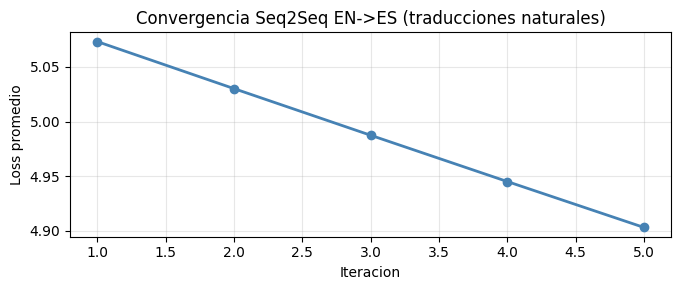

In [23]:
if losses_train:
    plt.figure(figsize=(7,3))
    plt.plot(range(1,6), losses_train, 'o-', color='steelblue', linewidth=2)
    plt.xlabel('Iteracion'); plt.ylabel('Loss promedio')
    plt.title('Convergencia Seq2Seq EN->ES (traducciones naturales)')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig('convergencia_seq2seq.png', dpi=110, bbox_inches='tight')
    plt.show()

---
## Bloque 12: Preguntas de analisis

---

### Pregunta 1 (35 pts)

El corpus tiene tres tipos de pares: traducciones mas cortas en espanol (elision del sujeto: *she sings well* -> *canta bien*), mas largas (perifrasis: *the cat sleeps* -> *el gato esta durmiendo*), y del mismo largo.

a) Durante el entrenamiento con teacher forcing, el decoder para el par (*she sings well*, *canta bien*) corre 2 pasos y para (*the cat sleeps*, *el gato esta durmiendo*) corre 4 pasos. Explique como afecta esa diferencia al gradiente que llega a los pesos del encoder en cada caso. Use la formula del recorrido del gradiente $S + T$ pasos.

b) Durante la inferencia greedy, el decoder debe aprender a generar EOS en el momento correcto. Para un par donde el espanol es mas corto que el ingles, ¿que debe haber aprendido el modelo para detener la generacion antes de que el decoder produzca tantos tokens como el encoder proceso? ¿Que informacion del encoder codifica esa senal de parada?

c) Si ordenara el corpus de entrenamiento de menor a mayor largo de la secuencia de salida (curriculum learning), ¿esperaria que el modelo convergiera mas rapido, mas lento, o igual? Justifique en terminos del gradiente y del proceso de aprendizaje.

**Su respuesta a la Pregunta 1:**

a) 

b) 

c) 

---
### Pregunta 2 (35 pts)

a) En el Bloque 10 evalua el porcentaje de oraciones donde la primera palabra generada es correcta. Explique por que esa metrica es mas informativa que la loss de entrenamiento para evaluar la calidad de un sistema de traduccion, y cuales son sus limitaciones.

b) El Bloque 7 muestra que solo una fraccion de las columnas de `E_enc` tienen gradiente no cero en cada actualizacion. Con 78 pares de entrenamiento y 158 palabras en el vocabulario ingles, estime cuantas palabras del vocabulario podrian nunca recibir gradiente durante 5 iteraciones, y que implicacion tiene eso para la representacion de esas palabras.

c) Si quisiera extender este modelo para traducir del espanol al ingles ademas de del ingles al espanol (un solo modelo bidireccional), describa dos enfoques arquitectonicos distintos y justifique cual de los dos preserva mejor la informacion aprendida en este laboratorio.

**Su respuesta a la Pregunta 2:**

a) 

b) 

c) 

---
### Pregunta 3 (30 pts)

a) Si convirtiera este seq2seq en un autoencoder para comprimir oraciones en espanol, describa exactamente los tres cambios de codigo necesarios en el Bloque 9. Sea especifico sobre la funcion de perdida, los tokens de entrada y salida del decoder, y los vocabularios.

b) En el seq2seq, el backward fluye desde la perdida hasta `E_enc` a traves de $S + T$ pasos. En un autoencoder sobre el mismo corpus, ¿ese recorrido seria el mismo, mas corto o mas largo? Justifique considerando que las oraciones de entrada y salida son iguales.

c) El vector de contexto $\mathbf{c}$ de dimension 32 debe comprimir toda la informacion de la entrada. Para las oraciones mas largas del corpus (*nosotros nos reunimos cada semana*, 5 palabras), ¿es suficiente esa dimension? ¿Que pasaria con la calidad de la reconstruccion si redujera la dimension a 2?

**Su respuesta a la Pregunta 3:**

a) 

b) 

c) 

---
## Bloque 13: Nota automatica sobre la seccion de codigo

In [ ]:
_PUNTOS = {
    'b2': ('Bloque 2:  Encoder forward',           18),
    'b4': ('Bloque 4:  Perdida CE categorica',       8),
    'b5': ('Bloque 5:  Backward decoder',           14),
    'b6': ('Bloque 6:  Backward encoder',           10),
    'b7': ('Bloque 7:  dE completa vs diccionario',  5),
    'b8': ('Bloque 8:  Actualizacion de pesos',      2),
    'b9': ('Bloque 9:  Convergencia 5 iteraciones',  3),
}
_TOTAL = 60
print('=' * 62)
print('  NOTA AUTOMATICA - SECCION DE CODIGO')
print('=' * 62)
_obtenido = 0
for key, (nombre, pts_max) in _PUNTOS.items():
    val = _resultados.get(key, False)
    pts = pts_max if val is True else 0
    _obtenido += pts
    print(f'  {"CORRECTO" if val is True else "PENDIENTE":10s} | {nombre:38s} | {pts:2d}/{pts_max} pts')
if isinstance(_resultados.get('b10'), float):
    print(f'  INFO       | B10 primera palabra test: {_resultados["b10"]:.1f}%')
print('-' * 62)
print(f'  Subtotal codigo:   {_obtenido}/{_TOTAL} puntos')
print('  Pendiente manual:')
print('    Bloque 12 preguntas : __/25 pts')
print('    Comentarios codigo  : __/15 pts')
print('-' * 62)
print('  TOTAL FINAL (sobre 100): __/100 pts')
print('=' * 62)